In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_recall_curve, auc

import duckdb
from pathlib import Path
from xgboost import XGBClassifier
import optuna

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
#Load data

SAML_CSV = Path("C:/Users/chris/Documents/Projects/Data/SAML-D.csv")

CFG = {
    "seed": 42,
    "ctr_threshold": 10_000,      # structuring reference threshold
    "struct_band": 0.10,          # "just under" = within 10% below threshold
    "windows_days": [1, 7, 30],
    "sample_accounts": 60_000,    # set None to use the full population
}
rng = np.random.default_rng(CFG["seed"])

con = duckdb.connect()  # in-memory; add a path arg to persist
pd.set_option("display.width", 160)
#df = pd.read_csv("C:/Users/chris/Documents/Projects/Data/SAML-D.csv")

In [4]:
con.execute(f"""
CREATE OR REPLACE VIEW raw AS
SELECT * FROM read_csv_auto('{SAML_CSV.as_posix()}', header=true, sample_size=200000)
""")

schema = con.execute("DESCRIBE raw").df()
print(schema, "\n")
print("rows:", con.execute("SELECT COUNT(*) FROM raw").fetchone()[0])

               column_name column_type null   key default extra
0                     Time        TIME  YES  None    None  None
1                     Date        DATE  YES  None    None  None
2           Sender_account      BIGINT  YES  None    None  None
3         Receiver_account      BIGINT  YES  None    None  None
4                   Amount      DOUBLE  YES  None    None  None
5         Payment_currency     VARCHAR  YES  None    None  None
6        Received_currency     VARCHAR  YES  None    None  None
7     Sender_bank_location     VARCHAR  YES  None    None  None
8   Receiver_bank_location     VARCHAR  YES  None    None  None
9             Payment_type     VARCHAR  YES  None    None  None
10           Is_laundering      BIGINT  YES  None    None  None
11         Laundering_type     VARCHAR  YES  None    None  None 

rows: 9504852


In [5]:
# Normalise to a single timestamp + stable txn id. Adjust the two casts if
# cell 1 showed Date/Time already parsed as DATE/TIME (then drop the CASTs).
con.execute("""
CREATE OR REPLACE VIEW txn AS
SELECT
    ROW_NUMBER() OVER (ORDER BY "Date", "Time") AS txn_id,
    (CAST("Date" AS DATE) + CAST("Time" AS TIME))  AS ts,
    CAST("Date" AS DATE)                           AS dt,
    CAST("Sender_account"   AS VARCHAR)            AS sender,
    CAST("Receiver_account" AS VARCHAR)            AS receiver,
    CAST("Amount" AS DOUBLE)                       AS amount,
    "Payment_currency"      AS pay_ccy,
    "Received_currency"     AS rcv_ccy,
    "Sender_bank_location"  AS sender_loc,
    "Receiver_bank_location" AS receiver_loc,
    "Payment_type"          AS pay_type,
    CAST("Is_laundering" AS INTEGER)               AS y,
    "Laundering_type"                              AS typology
FROM raw
""")

con.execute("SELECT * FROM txn LIMIT 5").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,txn_id,ts,dt,sender,receiver,amount,pay_ccy,rcv_ccy,sender_loc,receiver_loc,pay_type,y,typology
0,1,2022-10-07 10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,2,2022-10-07 10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,3,2022-10-07 10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,4,2022-10-07 10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,5,2022-10-07 10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [6]:
print(con.execute("""
SELECT COUNT(*) AS n, SUM(y) AS positives,
       100.0*SUM(y)/COUNT(*) AS pct_positive
FROM txn
""").df())

typo = con.execute("""
SELECT typology, y, COUNT(*) AS n, SUM(amount) AS total_amount
FROM txn GROUP BY 1,2 ORDER BY y DESC, n DESC
""").df()
print(typo.to_string(index=False))

         n  positives  pct_positive
0  9504852     9873.0      0.103873


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

              typology  y       n  total_amount
           Structuring  1    1870  9.809655e+06
       Cash_Withdrawal  1    1334  2.058677e+05
          Deposit-Send  1     945  8.675891e+06
              Smurfing  1     932  2.612341e+06
        Layered_Fan_In  1     656  1.160257e+07
       Layered_Fan_Out  1     529  4.564555e+06
     Stacked Bipartite  1     506  4.921626e+06
  Behavioural_Change_1  1     394  1.922131e+06
             Bipartite  1     383  4.515827e+06
                 Cycle  1     382  1.070581e+07
                Fan_In  1     364  4.463610e+06
        Gather-Scatter  1     354  4.036811e+06
  Behavioural_Change_2  1     345  1.696055e+06
        Scatter-Gather  1     338  3.607138e+06
          Single_large  1     250  6.336835e+07
               Fan_Out  1     237  2.870652e+06
        Over-Invoicing  1      54  2.611431e+08
  Normal_Small_Fan_Out  0 3477717  1.635816e+10
        Normal_Fan_Out  0 2302220  2.322695e+10
         Normal_Fan_In  0 2104285  2.252

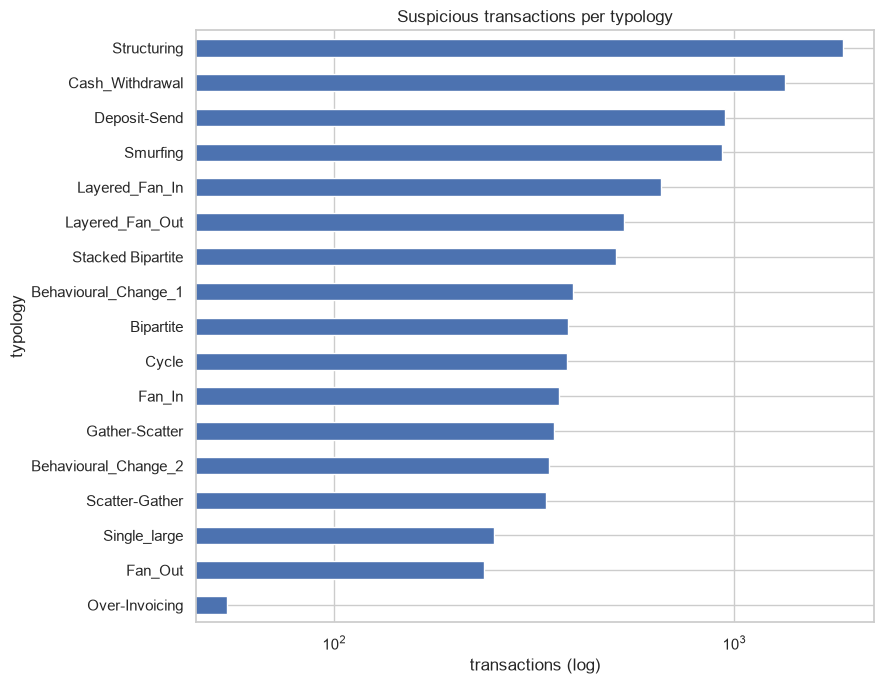

In [7]:
# How rare is the rarest typology? Anything in the low hundreds will be
# unlearnable individually -- we can report on this, but not performance.
susp = typo[typo.y == 1].sort_values("n")
ax = susp.plot.barh(x="typology", y="n", figsize=(9, 7), legend=False, logx=True)
ax.set_xlabel("transactions (log)"); ax.set_title("Suspicious transactions per typology")
plt.tight_layout(); plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

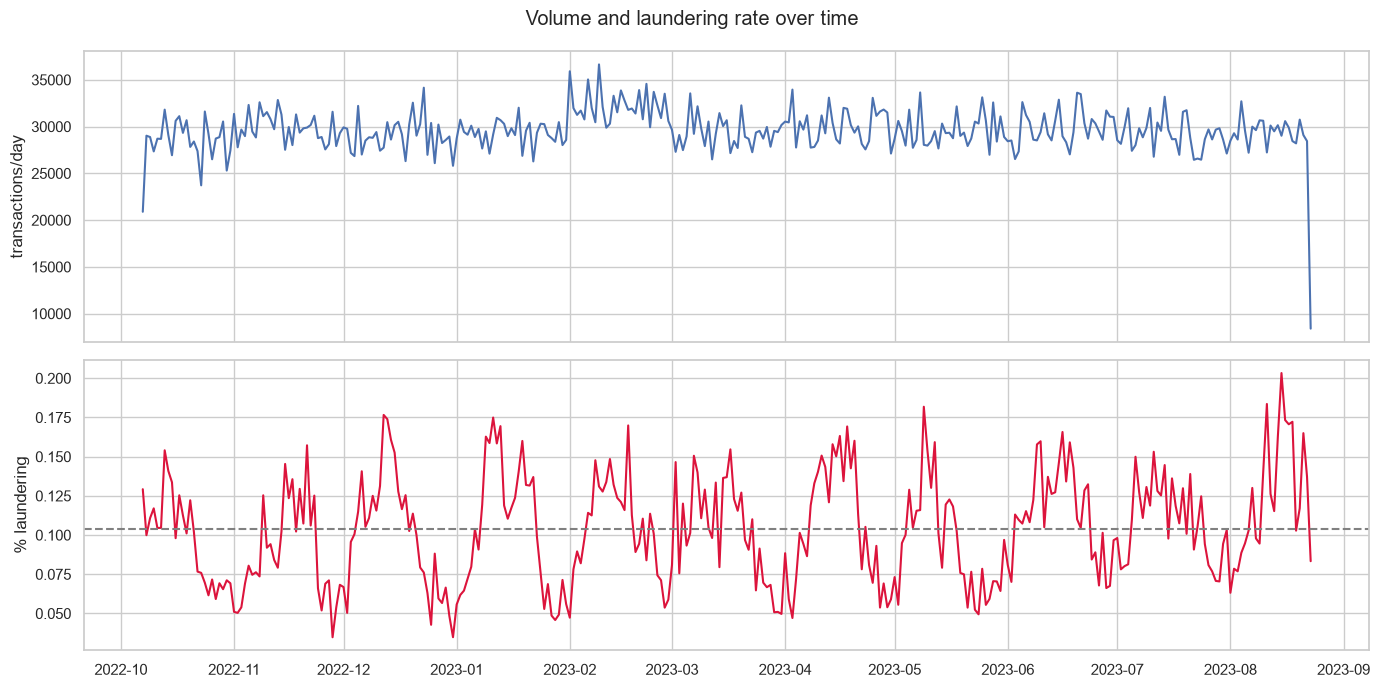

2022-10-07 00:00:00 -> 2023-08-23 00:00:00 | 321 days
proposed split: 2023-05-19 00:00:00


In [8]:
daily = con.execute("""
SELECT dt, COUNT(*) AS n, SUM(y) AS pos, 100.0*SUM(y)/COUNT(*) AS pct_pos
FROM txn GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax[0].plot(daily.dt, daily.n); ax[0].set_ylabel("transactions/day")
ax[1].plot(daily.dt, daily.pct_pos, color="crimson"); ax[1].set_ylabel("% laundering")
ax[1].axhline(daily.pct_pos.mean(), ls="--", c="grey")
plt.suptitle("Volume and laundering rate over time"); plt.tight_layout(); plt.show()

print(daily.dt.min(), "->", daily.dt.max(), "|", len(daily), "days")
# Chronological 70/30. Confirm the tail period isn't anomalous before committing.
SPLIT_DATE = daily.dt.quantile(0.7)
print("proposed split:", SPLIT_DATE)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   y  pct_just_under  pct_round_1k
0  1        0.036058      0.000000
1  0        0.047325      0.000009


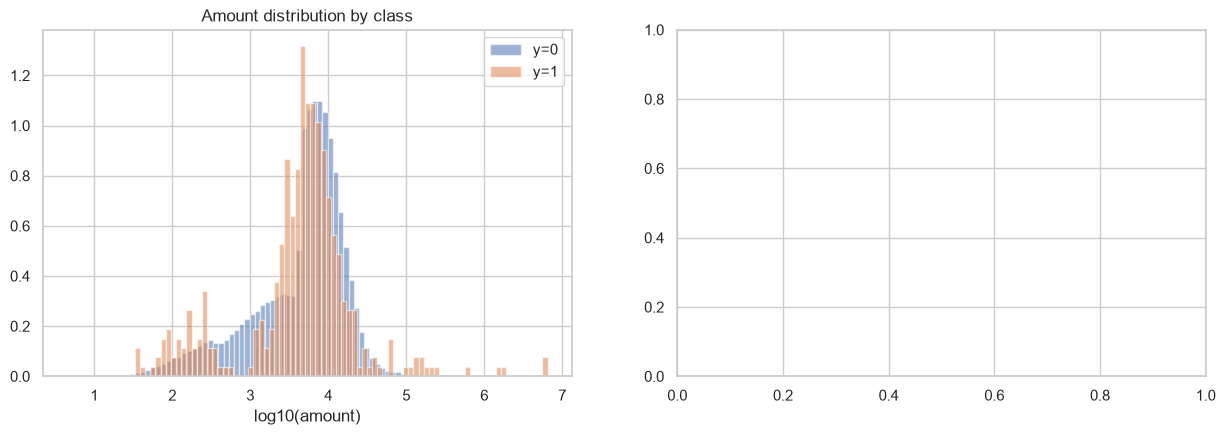

In [9]:
amt = con.execute("SELECT y, amount FROM txn USING SAMPLE 400000 ROWS").df()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for cls, sub in amt.groupby("y"):
    ax[0].hist(np.log10(sub.amount.clip(lower=1)), bins=80, alpha=.55,
               density=True, label=f"y={cls}")
ax[0].set_xlabel("log10(amount)"); ax[0].legend(); ax[0].set_title("Amount distribution by class")

near = con.execute(f"""
SELECT y,
       AVG(CASE WHEN amount BETWEEN {CFG['ctr_threshold']}*(1-{CFG['struct_band']})
                              AND {CFG['ctr_threshold']} THEN 1 ELSE 0 END) AS pct_just_under,
       AVG(CASE WHEN amount % 1000 = 0 THEN 1 ELSE 0 END) AS pct_round_1k
FROM txn GROUP BY 1
""").df()
print(near) 

In [10]:
def risk_table(col, min_n=500):
    return con.execute(f"""
        SELECT {col} AS value, COUNT(*) AS n, SUM(y) AS pos,
               100.0*SUM(y)/COUNT(*) AS pct_pos
        FROM txn GROUP BY 1 HAVING COUNT(*) >= {min_n}
        ORDER BY pct_pos DESC
    """).df()

for c in ["pay_type", "sender_loc", "receiver_loc", "pay_ccy"]:
    print(f"\n=== {c} ===")
    print(risk_table(c).head(12).to_string(index=False))


=== pay_type ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

          value       n    pos  pct_pos
   Cash Deposit  225206 1405.0 0.623873
Cash Withdrawal  300477 1334.0 0.443961
   Cross-border  933931 2628.0 0.281391
            ACH 2008807 1159.0 0.057696
    Credit card 2012909 1136.0 0.056436
     Debit card 2012103 1124.0 0.055862
         Cheque 2011419 1087.0 0.054041

=== sender_loc ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      value     n  pos  pct_pos
    Morocco 18437 55.0 0.298313
     Mexico 17662 44.0 0.249122
Netherlands 16770 41.0 0.244484
      India 17596 42.0 0.238691
      Italy 18895 45.0 0.238158
    Germany 19259 43.0 0.223272
    Austria 18050 38.0 0.210526
      Japan 18468 38.0 0.205761
Switzerland 20503 41.0 0.199971
        USA 19027 36.0 0.189205
        UAE 20081 34.0 0.169314
     France 18702 31.0 0.165758

=== receiver_loc ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      value     n   pos  pct_pos
    Nigeria 38272 251.0 0.655832
    Morocco 38704 253.0 0.653679
    Albania 38783 235.0 0.605936
        UAE 35897 195.0 0.543221
     Mexico 38385 197.0 0.513221
     Turkey 35586 177.0 0.497387
   Pakistan 38980 169.0 0.433556
Netherlands 37314 148.0 0.396634
    Austria 38844 154.0 0.396458
      India 36936 137.0 0.370912
      Italy 36517 131.0 0.358737
    Germany 38540 102.0 0.264660

=== pay_ccy ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

          value      n   pos  pct_pos
Moroccan dirham  25395  90.0 0.354400
         Dirham  27263  89.0 0.326450
    Swiss franc  27492  82.0 0.298269
   Indian rupee  24657  68.0 0.275784
   Mexican Peso  24852  68.0 0.273620
   Turkish lira  27996  73.0 0.260752
   Albanian lek  24778  64.0 0.258294
            Yen  25562  65.0 0.254284
      US dollar  26061  60.0 0.230229
          Naira  27143  62.0 0.228420
Pakistani rupee  27196  62.0 0.227975
           Euro 117164 260.0 0.221911


In [11]:
# Corridors -- the strongest single categorical signal in most AML data.
corr = con.execute("""
SELECT sender_loc || ' -> ' || receiver_loc AS corridor,
       COUNT(*) AS n, 100.0*SUM(y)/COUNT(*) AS pct_pos
FROM txn GROUP BY 1 HAVING COUNT(*) >= 1000
ORDER BY pct_pos DESC LIMIT 20
""").df()
print(corr.to_string(index=False))

# Cross-currency / cross-border prevalence by class
print(con.execute("""
SELECT y, AVG(CASE WHEN sender_loc <> receiver_loc THEN 1 ELSE 0 END) AS pct_xborder,
          AVG(CASE WHEN pay_ccy   <> rcv_ccy      THEN 1 ELSE 0 END) AS pct_xccy
FROM txn GROUP BY 1
""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         corridor     n  pct_pos
    UK -> Morocco 37146 0.659560
    UK -> Nigeria 36579 0.645179
    UK -> Albania 36788 0.578993
        UK -> UAE 34336 0.559180
     UK -> Mexico 36977 0.527355
     UK -> Turkey 34126 0.506945
   UK -> Pakistan 37595 0.425589
    UK -> Austria 37360 0.406852
UK -> Netherlands 35782 0.394053
      UK -> India 35533 0.363043
      UK -> Italy 34856 0.344274
    Morocco -> UK 16990 0.264862
    UK -> Germany 37056 0.261766
        UK -> USA 35410 0.228749
      UK -> Spain 35886 0.222928
Netherlands -> UK 14985 0.213547
UK -> Switzerland 34402 0.206383
      UK -> Japan 37130 0.204686
     UK -> France 37043 0.202467
    Austria -> UK 16812 0.202236


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   y  pct_xborder  pct_xccy
0  1     0.308417  0.370404
1  0     0.098084  0.113977


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

accounts: 855460
accounts touching >=1 suspicious txn: 7902
count    855460.000000
mean         22.221616
std          77.193688
min           1.000000
50%          12.000000
90%          17.000000
99%         522.000000
99.9%       810.000000
max        1498.000000
Name: n_txn, dtype: float64


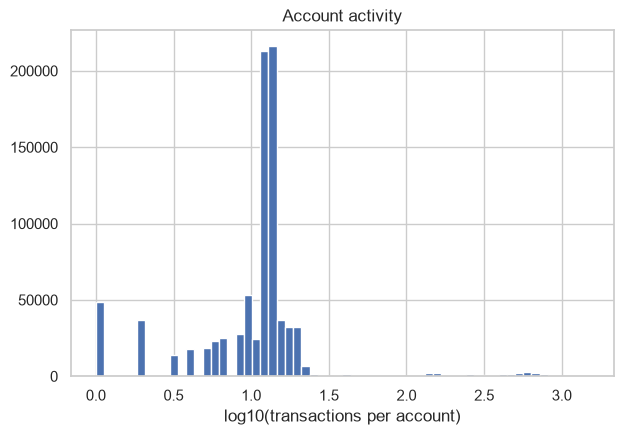

In [12]:
acct = con.execute("""
WITH legs AS (
    SELECT sender AS account, y FROM txn
    UNION ALL SELECT receiver, y FROM txn
)
SELECT account, COUNT(*) AS n_txn, SUM(y) AS n_susp
FROM legs GROUP BY 1
""").df()

print("accounts:", len(acct))
print("accounts touching >=1 suspicious txn:", (acct.n_susp > 0).sum())
print(acct.n_txn.describe(percentiles=[.5, .9, .99, .999]))

plt.figure(figsize=(7,4.5))
plt.hist(np.log10(acct.n_txn), bins=60)
plt.xlabel("log10(transactions per account)"); plt.title("Account activity"); plt.show()

In [27]:
susp_accounts = set(acct.loc[acct.n_susp > 0, "account"])
clean_pool    = acct.loc[acct.n_susp == 0, "account"].values

if CFG["sample_accounts"]:
    n_clean = max(0, CFG["sample_accounts"] - len(susp_accounts))
    keep = susp_accounts | set(rng.choice(clean_pool, size=min(n_clean, len(clean_pool)),
                                          replace=False))
else:
    keep = set(acct.account)

con.register("keep_accounts", pd.DataFrame({"account": list(keep)}))
con.execute("""
CREATE OR REPLACE TABLE txn_s AS
SELECT t.* FROM txn t
WHERE t.sender IN (SELECT account FROM keep_accounts)
   OR t.receiver IN (SELECT account FROM keep_accounts)
""")

print(con.execute("""
SELECT COUNT(*) n, SUM(y) pos, 100.0*SUM(y)/COUNT(*) pct FROM txn_s
""").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

         n     pos      pct
0  2461050  9873.0  0.40117


In [28]:
con.execute("""
CREATE OR REPLACE TABLE legs AS
SELECT txn_id, ts, sender AS account, receiver AS counterparty,
       'OUT' AS direction, amount, pay_type, sender_loc AS own_loc,
       receiver_loc AS cp_loc, y
FROM txn_s
UNION ALL
SELECT txn_id, ts, receiver, sender,
       'IN', amount, pay_type, receiver_loc, sender_loc, y
FROM txn_s
""")
con.execute("CREATE INDEX idx_legs ON legs(account, ts)")
print(con.execute("SELECT COUNT(*) FROM legs").fetchone()[0], "legs")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

4922100 legs


In [29]:
win_sql = []
for d in CFG["windows_days"]:
    win_sql += [
        f"COUNT(*)   OVER w{d} AS cnt_{d}d",
        f"SUM(amount) OVER w{d} AS sum_{d}d",
        f"AVG(amount) OVER w{d} AS avg_{d}d",
        f"MAX(amount) OVER w{d} AS max_{d}d",
    ]
win_defs = ", ".join(
    f"w{d} AS (PARTITION BY account, direction ORDER BY ts "
    f"RANGE BETWEEN INTERVAL {d} DAY PRECEDING AND CURRENT ROW)"
    for d in CFG["windows_days"]
)

con.execute(f"""
CREATE OR REPLACE TABLE leg_feat AS
SELECT txn_id, account, direction, ts, amount,
       {", ".join(win_sql)},
       -- dormancy: seconds since this account's previous activity
       date_diff('second',
                 LAG(ts) OVER (PARTITION BY account, direction ORDER BY ts),
                 ts) AS secs_since_prev,
       -- behavioural change: amount vs the account's own trailing profile
       AVG(amount) OVER (PARTITION BY account, direction ORDER BY ts
                         ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING) AS trail_avg_20,
       STDDEV_SAMP(amount) OVER (PARTITION BY account, direction ORDER BY ts
                         ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING) AS trail_std_20
FROM legs
WINDOW {win_defs}
""")
con.execute("SELECT * FROM leg_feat LIMIT 5").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,txn_id,account,direction,ts,amount,cnt_1d,sum_1d,avg_1d,max_1d,cnt_7d,sum_7d,avg_7d,max_7d,cnt_30d,sum_30d,avg_30d,max_30d,secs_since_prev,trail_avg_20,trail_std_20
0,1681623,5136934785,IN,2022-12-03 16:20:06,17864.39,107,1262194.73,11796.212430,29653.86,107,1262194.73,11796.212430,29653.86,107,1262194.73,11796.212430,29653.86,135,11149.8465,6449.390470
1,1681639,5136934785,IN,2022-12-03 16:20:22,7183.25,108,1269377.98,11753.499815,29653.86,108,1269377.98,11753.499815,29653.86,108,1269377.98,11753.499815,29653.86,16,11556.1410,6609.760734
2,1681721,5136934785,IN,2022-12-03 16:23:35,11586.08,109,1280964.06,11751.963853,29653.86,109,1280964.06,11751.963853,29653.86,109,1280964.06,11751.963853,29653.86,193,11333.7030,6681.540354
3,1681959,5136934785,IN,2022-12-03 16:32:41,4665.28,110,1285629.34,11687.539455,29653.86,110,1285629.34,11687.539455,29653.86,110,1285629.34,11687.539455,29653.86,546,11328.4270,6681.284527
4,1682072,5136934785,IN,2022-12-03 16:36:33,4656.67,111,1290286.01,11624.198288,29653.86,111,1290286.01,11624.198288,29653.86,111,1290286.01,11624.198288,29653.86,232,11203.4835,6785.804855


In [30]:
# Per-account directional flow.
# Partitioned by account ONLY (not account+direction) so each leg row can see
# that same account's inflow AND outflow over the window -- which is what a
# pass-through / mule ratio actually requires.
con.execute("""
CREATE OR REPLACE TABLE acct_flow AS
SELECT txn_id, account, direction, ts,
       SUM(CASE WHEN direction='IN'  THEN amount ELSE 0 END) OVER w7 AS in_7d,
       SUM(CASE WHEN direction='OUT' THEN amount ELSE 0 END) OVER w7 AS out_7d
FROM legs
WINDOW w7 AS (PARTITION BY account ORDER BY ts
              RANGE BETWEEN INTERVAL 7 DAY PRECEDING AND CURRENT ROW)
""")
con.execute("SELECT * FROM acct_flow LIMIT 5").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,txn_id,account,direction,ts,in_7d,out_7d
0,5142087,4034729062,OUT,2023-03-29 07:42:59,0.0,2928.14
1,5215981,4034729062,OUT,2023-03-31 16:30:56,0.0,2841.08
2,5560816,4034729062,OUT,2023-04-12 08:04:19,0.0,4799.47
3,5716293,4034729062,OUT,2023-04-17 11:07:54,0.0,7215.60
4,6043844,4034729062,OUT,2023-04-28 07:31:49,0.0,712.12


In [31]:
FAN_WINDOW = 7
con.execute(f"""
CREATE OR REPLACE TABLE fan_feat AS
SELECT l.txn_id, l.direction,
       COUNT(DISTINCT l2.counterparty) AS n_cp_{FAN_WINDOW}d,
       COUNT(*)                        AS n_txn_{FAN_WINDOW}d
FROM legs l
JOIN legs l2
  ON l2.account = l.account
 AND l2.direction = l.direction
 AND l2.ts <= l.ts
 AND l2.ts >  l.ts - INTERVAL {FAN_WINDOW} DAY
GROUP BY 1, 2
""")
print(con.execute("SELECT * FROM fan_feat LIMIT 5").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    txn_id direction  n_cp_7d  n_txn_7d
0  7640373       OUT        1        12
1  7640099       OUT        1        12
2  7613049       OUT        1         1
3  7637509       OUT        1        12
4  7634668       OUT        1        12


In [32]:
# Assemble the transaction-level feature matrix.
#  - sender/receiver carried through: the rule engine alerts on accounts
#  - sum_1d surfaced from leg_feat: needed by the structuring scenario
#  - pass-through ratio now compares each account against ITSELF (via acct_flow)
con.execute(f"""
CREATE OR REPLACE TABLE features AS
WITH s   AS (SELECT * FROM leg_feat WHERE direction = 'OUT'),
     r   AS (SELECT * FROM leg_feat WHERE direction = 'IN'),
     sfl AS (SELECT txn_id, in_7d, out_7d FROM acct_flow WHERE direction = 'OUT'),
     rfl AS (SELECT txn_id, in_7d, out_7d FROM acct_flow WHERE direction = 'IN'),
     sf  AS (SELECT txn_id, n_cp_7d AS snd_n_cp_7d FROM fan_feat WHERE direction='OUT'),
     rf  AS (SELECT txn_id, n_cp_7d AS rcv_n_cp_7d FROM fan_feat WHERE direction='IN')
SELECT
    t.txn_id, t.ts, t.dt, t.y, t.typology,
    t.sender, t.receiver,
    t.amount, t.pay_type, t.pay_ccy, t.rcv_ccy, t.sender_loc, t.receiver_loc,

    -- transaction-intrinsic
    log10(t.amount + 1)                                        AS log_amount,
    CASE WHEN t.sender_loc <> t.receiver_loc THEN 1 ELSE 0 END AS is_xborder,
    CASE WHEN t.pay_ccy    <> t.rcv_ccy      THEN 1 ELSE 0 END AS is_xccy,
    CASE WHEN t.amount % 1000 = 0 THEN 1 ELSE 0 END             AS is_round_1k,
    CASE WHEN t.amount BETWEEN {CFG['ctr_threshold']}*(1-{CFG['struct_band']})
                           AND {CFG['ctr_threshold']} THEN 1 ELSE 0 END AS is_just_under_ctr,
    hour(t.ts)                                                 AS hour_of_day,
    CASE WHEN dayofweek(t.ts) IN (0,6) THEN 1 ELSE 0 END        AS is_weekend,

    -- sender-side velocity
    s.cnt_1d AS snd_cnt_1d, s.cnt_7d AS snd_cnt_7d, s.cnt_30d AS snd_cnt_30d,
    s.sum_1d AS snd_sum_1d, s.sum_7d AS snd_sum_7d, s.max_7d AS snd_max_7d,
    s.secs_since_prev AS snd_dormancy,
    (t.amount - s.trail_avg_20) / NULLIF(s.trail_std_20, 0) AS snd_amount_z,

    -- receiver-side velocity
    r.cnt_1d AS rcv_cnt_1d, r.cnt_7d AS rcv_cnt_7d, r.cnt_30d AS rcv_cnt_30d,
    r.sum_1d AS rcv_sum_1d, r.sum_7d AS rcv_sum_7d,
    r.secs_since_prev AS rcv_dormancy,
    (t.amount - r.trail_avg_20) / NULLIF(r.trail_std_20, 0) AS rcv_amount_z,

    -- graph shape
    sf.snd_n_cp_7d, rf.rcv_n_cp_7d,
    sf.snd_n_cp_7d::DOUBLE / NULLIF(s.cnt_7d, 0) AS snd_cp_ratio,

    -- pass-through / mule: each account's own money-out vs money-in over 7d
    rfl.out_7d / NULLIF(rfl.in_7d, 0) AS rcv_passthru_ratio,
    sfl.out_7d / NULLIF(sfl.in_7d, 0) AS snd_passthru_ratio

FROM txn_s t
LEFT JOIN s   ON s.txn_id   = t.txn_id
LEFT JOIN r   ON r.txn_id   = t.txn_id
LEFT JOIN sf  ON sf.txn_id  = t.txn_id
LEFT JOIN rf  ON rf.txn_id  = t.txn_id
LEFT JOIN sfl ON sfl.txn_id = t.txn_id
LEFT JOIN rfl ON rfl.txn_id = t.txn_id
""")

feat = con.execute("SELECT * FROM features").df()
print(feat.shape)
feat.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(2461050, 40)


,txn_id,ts,dt,y,typology,sender,receiver,amount,pay_type,pay_ccy,rcv_ccy,sender_loc,receiver_loc,log_amount,is_xborder,is_xccy,is_round_1k,is_just_under_ctr,hour_of_day,is_weekend,snd_cnt_1d,snd_cnt_7d,snd_cnt_30d,snd_sum_1d,snd_sum_7d,snd_max_7d,snd_dormancy,snd_amount_z,rcv_cnt_1d,rcv_cnt_7d,rcv_cnt_30d,rcv_sum_1d,rcv_sum_7d,rcv_dormancy,rcv_amount_z,snd_n_cp_7d,rcv_n_cp_7d,snd_cp_ratio,rcv_passthru_ratio,snd_passthru_ratio
0,7611264,2023-06-20 08:26:22,2023-06-20,0,Normal_Small_Fan_Out,9273258089,3268245964,488.08,Cheque,UK pounds,UK pounds,UK,UK,2.689380,0,0,0,0,8,0,1,8,29,488.08,15100.43,7091.38,134795,-0.707044,1,1,3,488.08,488.08,979695,-1.725668,6,1,0.750000,0.000000,8.851729
1,7611265,2023-06-20 08:26:22,2023-06-20,0,Normal_Fan_In,5714690867,9694660801,7471.43,ACH,UK pounds,UK pounds,UK,UK,3.873462,0,0,0,0,8,0,2,2,2,14965.44,14965.44,7494.01,1071,NaN,39,40,42,384376.99,385578.91,237,-0.320606,1,17,0.500000,0.116734,NaN
2,7611266,2023-06-20 08:26:22,2023-06-20,0,Normal_Fan_In,5878978881,4818711914,12599.26,Cheque,UK pounds,UK pounds,UK,UK,4.100380,0,0,0,0,8,0,2,2,2,25154.77,25154.77,12599.26,3782,NaN,32,32,33,283676.34,283676.34,108,1.174155,1,15,0.500000,0.098342,NaN
3,7611271,2023-06-20 08:26:28,2023-06-20,0,Normal_Group,8645919989,5216531044,812.28,Credit card,UK pounds,UK pounds,UK,UK,2.910240,0,0,0,0,8,0,1,2,6,812.28,1476.34,812.28,509880,1.710074,3,15,61,3812.18,47361.07,42141,-0.879386,1,7,0.500000,1.354712,0.271302
4,7611272,2023-06-20 08:26:35,2023-06-20,0,Normal_Periodical,3108280261,1739657468,22035.96,Cross-border,UK pounds,Pakistani rupee,UK,Pakistan,4.343152,1,1,0,0,8,0,4,9,25,91065.70,108026.68,23252.85,7872,2.001009,4,4,4,91065.70,91065.70,7872,-4.537068,5,1,0.555556,0.000000,NaN


In [33]:
# Leakage guard, feature typing, and temporal split.
#
# LEAK_COLS         -- typology is the generator's answer key; sender/receiver are
#                      high-cardinality IDs the model must not memorise.
# DEAD_BY_MECHANISM -- SAML-D is GBP-denominated and its generator has no reporting-
#                      threshold concept, so these two flags cannot carry signal.
#                      Dropped from the model, but RETAINED in the rule engine below,
#                      where an unproductive structuring scenario is itself a finding.
#                      NB: prune on mechanism or permutation importance -- never on
#                      univariate AUC alone, which says nothing about interactions.
LEAK_COLS         = ["typology", "y", "txn_id", "ts", "dt", "sender", "receiver"]
DEAD_BY_MECHANISM = ["is_just_under_ctr", "is_round_1k"]
CAT_COLS          = ["pay_type", "pay_ccy", "rcv_ccy", "sender_loc", "receiver_loc"]

X_cols = [c for c in feat.columns if c not in LEAK_COLS + DEAD_BY_MECHANISM]

# Cast BEFORE splitting so train and test share identical category levels.
# Casting after would give a location seen only in test a mismatched code.
for c in CAT_COLS:
    feat[c] = feat[c].astype("category")

train = feat[feat.dt <  SPLIT_DATE]
test  = feat[feat.dt >= SPLIT_DATE]

print(f"train {len(train):,} rows, {train.y.sum():,} pos ({100*train.y.mean():.3f}%)")
print(f"test  {len(test):,} rows, {test.y.sum():,} pos ({100*test.y.mean():.3f}%)")

assert train.dt.max() < test.dt.min(), "temporal leakage across the split"

print("\nnull rates (high nulls = accounts with no prior history, expected early on):")
print(feat[X_cols].isna().mean().sort_values(ascending=False).head(10))

# Leakage tripwire: anything near 1.0 alone is encoding the label, not behaviour.
from sklearn.metrics import roc_auc_score
num_cols = feat[X_cols].select_dtypes(include=np.number).columns
sig = {c: roc_auc_score(feat.y, feat[c].fillna(feat[c].median())) for c in num_cols}
print("\ntop univariate AUCs:")
print(pd.Series(sig).sort_values(ascending=False).head(15))

train 1,730,201 rows, 6,774 pos (0.392%)
test  730,849 rows, 3,099 pos (0.424%)

null rates (high nulls = accounts with no prior history, expected early on):
snd_passthru_ratio    0.789270
rcv_amount_z          0.133416
rcv_dormancy          0.071314
snd_amount_z          0.068570
snd_dormancy          0.035256
pay_type              0.000000
amount                0.000000
is_xborder            0.000000
is_xccy               0.000000
hour_of_day           0.000000
dtype: float64

top univariate AUCs:
snd_dormancy          0.733995
snd_cp_ratio          0.715663
rcv_passthru_ratio    0.643649
rcv_dormancy          0.632359
is_xccy               0.629459
is_xborder            0.606242
rcv_n_cp_7d           0.560314
snd_amount_z          0.539582
rcv_amount_z          0.502582
is_weekend            0.493057
amount                0.486974
log_amount            0.486974
hour_of_day           0.481429
snd_max_7d            0.455750
snd_n_cp_7d           0.437635
dtype: float64


In [34]:
# Population re-weighting.
#
# Cell 12 kept every laundering-involved account but only a sample of clean ones,
# so the sampled base rate (~0.39%) is ~4x the true population rate (0.104%).
# Training on the enriched sample is fine and helpful. EVALUATION is not: precision
# is base-rate dependent, and every alert-volume projection downstream inherits it.
#
# All positives were retained, so only the negatives need re-weighting.
POP_ROWS, POP_POS = 9_504_852, 9_873          # from the full SAML-D file

neg_pop    = POP_ROWS - POP_POS
neg_sample = len(feat) - int(feat.y.sum())
W_NEG      = neg_pop / neg_sample

print(f"negatives: {neg_sample:,} sampled of {neg_pop:,} population")
print(f"enrichment factor W_NEG = {W_NEG:.3f}")
print(f"sampled base rate {100*feat.y.mean():.3f}%  ->  population {100*POP_POS/POP_ROWS:.3f}%")

def pop_weights(y):
    """Weights that restore population prevalence for any metric that accepts them."""
    return np.where(np.asarray(y) == 1, 1.0, W_NEG)

# CAVEAT: a constant weight corrects the aggregate base rate but not the fact that
# sampled clean accounts sit disproportionately NEAR suspicious ones. Use this for
# fast iteration; for published headline numbers, re-engineer features over the full
# unsampled post-split window (with a 30-day warm-up buffer) and evaluate there.

negatives: 2,451,177 sampled of 9,494,979 population
enrichment factor W_NEG = 3.874
sampled base rate 0.401%  ->  population 0.104%


In [35]:
# Baseline XGBoost.
#
# enable_categorical + tree_method="hist" let XGBoost split on the category dtype
# directly -- no one-hot needed. Without the astype("category") in the split cell,
# this raises: "DataFrame.dtypes for data must be int, float, bool or category".
#
# eval_metric is aucpr, not the default logloss: at a 0.1% base rate, ROC-AUC
# flatters badly and PR-AUC is what tracks analyst false-positive burden.
from sklearn.metrics import average_precision_score, roc_auc_score

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    enable_categorical=True,
    tree_method="hist",
    eval_metric="aucpr",
    n_jobs=-1,
    random_state=CFG["seed"],
)
xgb_base.fit(train[X_cols], train.y)

proba = xgb_base.predict_proba(test[X_cols])[:, 1]
w     = pop_weights(test.y)

ap_sampled = average_precision_score(test.y, proba)
ap_pop     = average_precision_score(test.y, proba, sample_weight=w)
roc        = roc_auc_score(test.y, proba)

print(f"ROC-AUC              {roc:.4f}   <- flattering, base-rate insensitive")
print(f"PR-AUC  (sampled)    {ap_sampled:.4f}")
print(f"PR-AUC  (population) {ap_pop:.4f}   <- report this one")
print(f"\ntest base rate: sampled {test.y.mean():.5f} -> population {POP_POS/POP_ROWS:.5f}")

print("\ntop 15 features by gain:")
print(pd.Series(xgb_base.feature_importances_, index=X_cols)
        .sort_values(ascending=False).head(15).to_string())

ROC-AUC              0.9959   <- flattering, base-rate insensitive
PR-AUC  (sampled)    0.8870
PR-AUC  (population) 0.8246   <- report this one

test base rate: sampled 0.00424 -> population 0.00104

top 15 features by gain:
snd_cnt_7d            0.283424
snd_n_cp_7d           0.181453
rcv_cnt_7d            0.106007
rcv_n_cp_7d           0.095690
rcv_cnt_1d            0.069611
is_xccy               0.032466
snd_cnt_30d           0.028231
snd_cp_ratio          0.022914
rcv_cnt_30d           0.020608
rcv_passthru_ratio    0.017296
snd_passthru_ratio    0.016240
amount                0.015167
pay_type              0.014543
rcv_dormancy          0.013847
snd_dormancy          0.009002


In [43]:
# ---------------------------------------------------------------------------
# RULE ENGINE BASELINE
# ---------------------------------------------------------------------------
# The rules-based system is the incumbent: it is what a real AML programme runs
# and what the regulator approved. Every later claim about the model is expressed
# as a delta against this baseline, so it has to be built first.
#
# R1: threshold calibration -- derived from TRAIN ONLY, never from test.
SPLIT_SQL = str(pd.Timestamp(SPLIT_DATE).date())
con.execute(f"CREATE OR REPLACE VIEW train_f AS SELECT * FROM features WHERE dt < DATE '{SPLIT_SQL}'")

# Thresholds are CALIBRATED on train, but the rule engine is SCORED on test only.
# Scoring rules over the whole period while the model is evaluated on the test
# period alone would make the two non-comparable -- the rules would be credited
# with detections from data the model was never allowed to see.
con.execute(f"CREATE OR REPLACE VIEW score_f AS SELECT * FROM features WHERE dt >= DATE '{SPLIT_SQL}'")
_n, _p, _d = con.execute("SELECT COUNT(*), SUM(y), COUNT(DISTINCT dt) FROM score_f").fetchone()
print(f"scoring period: {_d} days, {_n:,} transactions, {_p:,} suspicious\n")

def pct_by(segment_col, pct):
    """Amount percentile WITHIN each segment."""
    return (con.execute(f"""
        SELECT {segment_col} AS seg, quantile_cont(amount, {pct}) AS thr
        FROM train_f GROUP BY 1
    """).df().set_index("seg").thr.to_dict())

# Per-payment-type, because the distributions differ by orders of magnitude:
# Cash Withdrawal tops out around GBP 350 while the global 99.5th pct is ~GBP 69k.
# A single global amount threshold would leave the cash scenario permanently silent.
CASH_THR = pct_by("pay_type", 0.99)
print("99th pct of amount by payment type:")
for k, v in sorted(CASH_THR.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<18} {v:>12,.0f}")

AMT_P99 = con.execute("SELECT quantile_cont(amount, 0.99) FROM train_f").fetchone()[0]
print(f"\nglobal 99th pct: {AMT_P99:,.0f}")

# High-risk corridors, also train-only.
hr = con.execute("""
SELECT sender_loc||'>'||receiver_loc AS corridor, COUNT(*) AS n, AVG(y) AS rate
FROM train_f GROUP BY 1 HAVING COUNT(*) >= 2000
ORDER BY rate DESC LIMIT 8
""").df()
HR_LIST = "(" + ",".join(f"'{c}'" for c in hr.corridor) + ")"
print("\nhigh-risk corridors (train-derived):")
print(hr.to_string(index=False))

scoring period: 97 days, 730,849 transactions, 3,099 suspicious

99th pct of amount by payment type:
  ACH                      47,959
  Cross-border             47,728
  Cheque                   47,021
  Credit card              46,762
  Debit card               46,450
  Cash Deposit              5,892
  Cash Withdrawal             342

global 99th pct: 45,741

high-risk corridors (train-derived):
  corridor    n     rate
UK>Morocco 6148 0.026675
 UK>Turkey 5482 0.020248
UK>Nigeria 7278 0.019923
UK>Albania 7071 0.018809
    UK>UAE 6572 0.018716
 UK>Mexico 6714 0.018171
  UK>India 6520 0.016718
UK>Austria 6553 0.014345


In [44]:
# R2: scenario definitions.
# `subject` is the account the alert is raised against -- sender for outbound
# behaviour, receiver for inbound. Coverage is aimed at the typologies SAML-D
# actually contains (see the crosstab in the EDA section).
CASH_CASE = " ".join(f"WHEN '{k}' THEN {v}" for k, v in CASH_THR.items())

RULES = [
    ("R01_STRUCTURING", "sender",
     "snd_cnt_1d >= 5 AND amount < 10000 AND snd_sum_1d >= 15000"),

    ("R02_PASSTHROUGH", "receiver",
     f"rcv_passthru_ratio BETWEEN 0.85 AND 1.18 AND rcv_cnt_7d >= 3 "
     f"AND rcv_sum_7d > {AMT_P99:.0f}"),

    ("R03_HR_CORRIDOR", "sender",
     f"is_xborder = 1 AND (sender_loc||'>'||receiver_loc) IN {HR_LIST} "
     f"AND amount > {AMT_P99*0.25:.0f}"),

    ("R04_FAN_OUT", "sender",
     "snd_n_cp_7d >= 6 AND snd_cnt_7d >= 6"),

    ("R05_FAN_IN", "receiver",
     "rcv_n_cp_7d >= 6 AND rcv_cnt_7d >= 6"),

    ("R06_DORMANT", "sender",
     f"snd_dormancy > {30*86400} AND amount > {AMT_P99*0.5:.0f}"),

    ("R07_XCCY_LAYER", "receiver",
     "is_xccy = 1 AND is_xborder = 1 AND rcv_cnt_7d >= 4"),

    ("R08_LARGE_CASH", "sender",
     f"pay_type LIKE 'Cash%' AND amount > (CASE pay_type {CASH_CASE} ELSE 1e18 END)"),
]

union = "\nUNION ALL\n".join(
    f"SELECT '{rid}' AS rule_id, {subj} AS subject_account, txn_id, ts, dt, y, "
    f"typology, amount FROM score_f WHERE {cond}"
    for rid, subj, cond in RULES)
con.execute(f"CREATE OR REPLACE TABLE rule_hits AS {union}")

print(con.execute("""
SELECT rule_id, COUNT(*) AS txn_hits, SUM(y) AS susp_hits
FROM rule_hits GROUP BY 1 ORDER BY 1
""").df().to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

        rule_id  txn_hits  susp_hits
R01_STRUCTURING    169715       77.0
R02_PASSTHROUGH      5332        6.0
R03_HR_CORRIDOR      5172       76.0
    R04_FAN_OUT    272446      775.0
     R05_FAN_IN    142707      286.0
    R06_DORMANT      6791       70.0
 R07_XCCY_LAYER     40044      253.0
 R08_LARGE_CASH       386       87.0


In [45]:
# R3: collapse transaction hits into alerts.
#
# Real transaction monitoring raises ONE alert per account, per scenario, per
# period -- not one per transaction. Skipping this step inflates alert volume by
# an order of magnitude and makes any analyst-capacity figure meaningless.
con.execute("""
CREATE OR REPLACE TABLE alerts AS
SELECT rule_id, subject_account, dt,
       COUNT(*)    AS n_txn,
       SUM(amount) AS total_amount,
       MAX(y)      AS is_tp,          -- productive if ANY member txn is suspicious
       MIN(ts)     AS first_ts,
       STRING_AGG(DISTINCT CASE WHEN y=1 THEN typology END, '|') AS typologies
FROM rule_hits
GROUP BY 1, 2, 3
""")

n_hits   = con.execute("SELECT COUNT(*) FROM rule_hits").fetchone()[0]
n_alerts = con.execute("SELECT COUNT(*) FROM alerts").fetchone()[0]
print(f"{n_hits:,} transaction hits  ->  {n_alerts:,} account-day alerts "
      f"({n_hits/max(n_alerts,1):.1f} txns per alert)")

642,593 transaction hits  ->  128,025 account-day alerts (5.0 txns per alert)


In [46]:
# R4: the baseline scorecard -- the numbers the dashboard is built from.
ALERT_MINUTES    = 25   # analyst handling time per alert
PRODUCTIVE_HOURS = 6    # effective investigation hours per analyst per day

tot_pos = con.execute("SELECT SUM(y) FROM score_f").fetchone()[0]   # test period only

perf = con.execute("""
SELECT rule_id, COUNT(*) AS alerts, SUM(is_tp) AS tp_alerts,
       100.0*SUM(is_tp)/COUNT(*) AS productivity_pct
FROM alerts GROUP BY 1
""").df()
rec = con.execute("""
SELECT rule_id, COUNT(DISTINCT txn_id) AS caught
FROM rule_hits WHERE y = 1 GROUP BY 1
""").df()

perf = perf.merge(rec, on="rule_id", how="left").fillna({"caught": 0})
perf["recall_pct"]   = 100 * perf.caught / tot_pos
perf["analyst_days"] = perf.alerts * ALERT_MINUTES / 60 / PRODUCTIVE_HOURS

print("=== RULE BASELINE ===")
print(perf.sort_values("productivity_pct", ascending=False).to_string(index=False))

tot_alerts, tot_tp = con.execute("SELECT COUNT(*), SUM(is_tp) FROM alerts").fetchone()
caught = con.execute("SELECT COUNT(DISTINCT txn_id) FROM rule_hits WHERE y=1").fetchone()[0]
print(f"\nPORTFOLIO: {tot_alerts:,} alerts | {tot_tp:,} productive "
      f"({100*tot_tp/tot_alerts:.2f}%) | recall {100*caught/tot_pos:.1f}% "
      f"of {tot_pos:,} suspicious txns")
n_score_days = con.execute("SELECT COUNT(DISTINCT dt) FROM score_f").fetchone()[0]
print(f"implied effort: {perf.analyst_days.sum():,.0f} analyst-days over {n_score_days} days"
      f"  ({perf.analyst_days.sum()/n_score_days:,.0f} FTE to keep up)")

# Rules firing zero alerts are miscalibrated, not absent -- check before moving on.
silent = [rid for rid, _, _ in RULES if rid not in set(perf.rule_id)]
if silent:
    print(f"\nWARNING: no alerts from {silent} -- thresholds need recalibration")

=== RULE BASELINE ===
        rule_id  alerts  tp_alerts  productivity_pct  caught  recall_pct  analyst_days
 R08_LARGE_CASH     386       87.0         22.538860      87    2.807357     26.805556
 R07_XCCY_LAYER    4011      230.0          5.734231     253    8.163924    278.541667
R03_HR_CORRIDOR    1499       76.0          5.070047      76    2.452404    104.097222
     R05_FAN_IN   12024      267.0          2.220559     286    9.228783    835.000000
    R06_DORMANT    6791       70.0          1.030776      70    2.258793    471.597222
    R04_FAN_OUT   86798      653.0          0.752321     775   25.008067   6027.638889
R01_STRUCTURING   13610       62.0          0.455547      77    2.484672    945.138889
R02_PASSTHROUGH    2906        6.0          0.206469       6    0.193611    201.805556

PORTFOLIO: 128,025 alerts | 1,451 productive (1.13%) | recall 42.3% of 3,099 suspicious txns
implied effort: 8,891 analyst-days over 97 days  (92 FTE to keep up)


In [47]:
# R5: typology coverage and marginal rule value.
#
# Coverage gaps are the ML value proposition: whatever the rules structurally
# cannot see is what the model is being brought in to catch.
cov = con.execute("""
    SELECT typology, COUNT(*) AS total FROM score_f WHERE y = 1 GROUP BY 1
""").df().merge(
    con.execute("""
        SELECT typology, COUNT(DISTINCT txn_id) AS caught
        FROM rule_hits WHERE y = 1 GROUP BY 1
    """).df(), on="typology", how="left").fillna({"caught": 0})
cov["coverage_pct"] = 100 * cov.caught / cov.total

print("=== TYPOLOGY COVERAGE ===")
print(cov.sort_values("coverage_pct").to_string(index=False))

# Marginal value: what unique detection is lost if this rule is retired?
print("\n=== MARGINAL VALUE (unique suspicious txns per rule) ===")
rows = []
for rid, _, _ in RULES:
    uniq = con.execute(f"""
        SELECT COUNT(DISTINCT txn_id) FROM rule_hits
        WHERE y = 1 AND rule_id = '{rid}'
          AND txn_id NOT IN (SELECT txn_id FROM rule_hits WHERE y = 1 AND rule_id <> '{rid}')
    """).fetchone()[0]
    rows.append({"rule_id": rid, "unique_caught": uniq})
print(pd.DataFrame(rows).sort_values("unique_caught", ascending=False).to_string(index=False))

=== TYPOLOGY COVERAGE ===
            typology  total  caught  coverage_pct
           Bipartite     63      10     15.873016
            Smurfing    279      61     21.863799
      Layered_Fan_In    179      40     22.346369
     Layered_Fan_Out    152      35     23.026316
      Gather-Scatter    125      30     24.000000
      Scatter-Gather     89      22     24.719101
   Stacked Bipartite    219      57     26.027397
     Cash_Withdrawal    412     119     28.883495
      Over-Invoicing     21       7     33.333333
        Single_large     65      22     33.846154
               Cycle    114      48     42.105263
             Fan_Out    145      63     43.448276
        Deposit-Send    297     135     45.454545
         Structuring    556     321     57.733813
              Fan_In    102      61     59.803922
Behavioural_Change_1    133     133    100.000000
Behavioural_Change_2    148     148    100.000000

=== MARGINAL VALUE (unique suspicious txns per rule) ===
        rule_id 

In [48]:
# ---------------------------------------------------------------------------
# MODEL TUNING
# ---------------------------------------------------------------------------
# Yes -- this is where the model gets tuned, and it belongs BEFORE the hybrid
# comparison so that comparison uses the best model rather than a first guess.
#
# Two differences from the tuning in Fraud_Detection.ipynb:
#   1. CV must be TEMPORAL. A random KFold would train on future transactions and
#      score past ones; with velocity and counterparty features that leaks badly
#      and every fold score would be inflated.
#   2. The objective is average precision (PR-AUC), not F1 or accuracy. At a ~0.1%
#      base rate the threshold-dependent metrics are mostly noise.
import optuna
from sklearn.metrics import average_precision_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_FOLDS       = 3
N_TRIALS      = 30      # raise once you have seen one run end to end
TUNE_NEG_FRAC = 0.25    # negatives kept while tuning; final refit uses all data

# Rolling-origin folds: every validation block is strictly later than its training block.
train_days = np.sort(train.dt.unique())
bounds = np.array_split(train_days, N_FOLDS + 1)
FOLDS = []
for k in range(N_FOLDS):
    tr = (train.dt <= bounds[k][-1]).values
    va = ((train.dt > bounds[k][-1]) & (train.dt <= bounds[k + 1][-1])).values
    FOLDS.append((tr, va))
    print(f"fold {k}: train {tr.sum():>9,} ({int(train.y[tr].sum()):>5} pos)"
          f"  ->  val {va.sum():>9,} ({int(train.y[va].sum()):>5} pos)")

# Keep every positive, subsample negatives. This is for hyperparameter SELECTION
# only -- validation folds stay complete so the metric remains meaningful.
rng_t = np.random.default_rng(CFG["seed"])
tune_mask = ((train.y == 1) | (rng_t.random(len(train)) < TUNE_NEG_FRAC)).values
print(f"\ntuning subsample: {tune_mask.sum():,} of {len(train):,} rows")


def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 800, step=100),
        learning_rate    = trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        max_depth        = trial.suggest_int("max_depth", 3, 10),
        min_child_weight = trial.suggest_float("min_child_weight", 1, 50, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    )
    scores = []
    for tr_mask, va_mask in FOLDS:
        fit_mask = tr_mask & tune_mask
        m = XGBClassifier(**params, enable_categorical=True, tree_method="hist",
                          eval_metric="aucpr", n_jobs=-1, random_state=CFG["seed"])
        m.fit(train.loc[fit_mask, X_cols], train.y[fit_mask])
        p = m.predict_proba(train.loc[va_mask, X_cols])[:, 1]
        scores.append(average_precision_score(train.y[va_mask], p))
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=CFG["seed"]))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nbest CV PR-AUC: {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:<18} {v}")

fold 0: train   428,882 ( 1508 pos)  ->  val   420,628 ( 1749 pos)
fold 1: train   849,510 ( 3257 pos)  ->  val   446,133 ( 1801 pos)
fold 2: train 1,295,643 ( 5058 pos)  ->  val   434,558 ( 1716 pos)

tuning subsample: 437,570 of 1,730,201 rows


  0%|          | 0/30 [00:00<?, ?it/s]


best CV PR-AUC: 0.8320
  n_estimators       800
  learning_rate      0.024400573903413117
  max_depth          9
  min_child_weight   2.518825267538814
  subsample          0.8777718346547334
  colsample_bytree   0.6620708960286006
  reg_alpha          0.5940792658409926
  reg_lambda         2.9837901881756146


In [49]:
# Refit on the full training period and pick the model that actually wins.
#
# Tuning does not always beat the default, especially with few trials or a heavy
# negative subsample. Choose on the TEST PR-AUC you are going to report, keep the
# winner as model_final, and let everything downstream depend on that name only.
BEST = {**study.best_params, "enable_categorical": True, "tree_method": "hist",
        "eval_metric": "aucpr", "n_jobs": -1, "random_state": CFG["seed"]}

xgb_tuned   = XGBClassifier(**BEST).fit(train[X_cols], train.y)
proba_tuned = xgb_tuned.predict_proba(test[X_cols])[:, 1]

w      = pop_weights(test.y)
ap_base  = average_precision_score(test.y, proba, sample_weight=w)
ap_tuned = average_precision_score(test.y, proba_tuned, sample_weight=w)

print(f"population PR-AUC  baseline {ap_base:.4f}  |  tuned {ap_tuned:.4f}")
if ap_tuned >= ap_base:
    model_final, proba_final, MODEL_NAME = xgb_tuned, proba_tuned, "tuned"
else:
    model_final, proba_final, MODEL_NAME = xgb_base, proba, "baseline"
    print("  tuning did not improve on the default -- raise N_TRIALS or TUNE_NEG_FRAC")
print(f"using: {MODEL_NAME}")

population PR-AUC  baseline 0.8246  |  tuned 0.8604
using: tuned


In [50]:
# ---------------------------------------------------------------------------
# THRESHOLD SELECTION (out-of-fold)
# ---------------------------------------------------------------------------
# The model produces a SCORE, not a decision. Turning that score into an alert
# needs a cut-off, and the cut-off is not a hyperparameter -- it is chosen after
# the model is fitted, and it is the cheapest lever in the whole pipeline.
#
# The trap is choosing it on the test set. Sweeping thresholds on test and
# reporting the best one leaks the test set into the decision and inflates the
# result. So the sweep happens on OUT-OF-FOLD predictions from the TRAINING
# period: each score comes from a model that never saw that row.
#
# I reuse the same rolling-origin FOLDS as the tuning cell, so the out-of-fold
# scores are also free of any forward-looking leakage. Note this leaves the first
# training block without predictions -- that is inherent to temporal CV, and the
# remaining validation blocks are ample for choosing a cut-off.
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

oof = np.full(len(train), np.nan)
for tr_mask, va_mask in FOLDS:
    m = clone(model_final)
    m.fit(train.loc[tr_mask, X_cols], train.y[tr_mask])
    oof[va_mask] = m.predict_proba(train.loc[va_mask, X_cols])[:, 1]

have    = ~np.isnan(oof)
p_oof   = oof[have]
y_oof   = train.y.values[have]
oof_days = train.dt[have].nunique()
print(f"out-of-fold scores for {have.sum():,} of {len(train):,} training rows "
      f"({int(y_oof.sum()):,} suspicious, {oof_days} days)")

precision, recall, thresholds = precision_recall_curve(y_oof, p_oof)
precision, recall = precision[:-1], recall[:-1]   # curve returns one extra point

# --- Strategy 1: best F1 ----------------------------------------------------
# The balanced reference point, for when a missed case and a false alarm are
# treated as comparably costly.
f1   = 2 * precision * recall / (precision + recall + 1e-12)
t_f1 = thresholds[np.argmax(f1)]

# --- Strategy 2: alert capacity --------------------------------------------
# The operating point an AML team actually lives under: the review team can work
# N alerts a day, so the threshold is set by headcount, not by any statistical
# criterion. This is the strategy the hybrid comparison below uses.
#
# (The fraud-detection project covers the third strategy -- fixing a recall
# target and maximising precision -- and shows how expensive it becomes at a low
# base rate, so it is not repeated here.)
ANALYSTS               = 5
ALERTS_PER_ANALYST_DAY = 14

budget   = min(ANALYSTS * ALERTS_PER_ANALYST_DAY * oof_days, len(p_oof))
t_budget = np.sort(p_oof)[::-1][budget - 1]

print(f"\nbest-F1 threshold  {t_f1:.6f}")
print(f"capacity threshold {t_budget:.6f}  ({budget:,} alerts over {oof_days} days)")

out-of-fold scores for 1,301,319 of 1,730,201 training rows (5,266 suspicious, 168 days)

best-F1 threshold  0.285624
capacity threshold 0.022079  (11,760 alerts over 168 days)


In [51]:
# Apply the out-of-fold thresholds to the untouched test period.
#
# The thresholds were chosen without ever looking at test, so these numbers are
# honest. Watch the PR-AUC column: it is IDENTICAL on every row.
from sklearn.metrics import average_precision_score

w_test = pop_weights(test.y)
ap_pop = average_precision_score(test.y, proba_final, sample_weight=w_test)

rows = []
for name, t in [("default 0.5", 0.5),
                ("best F1 (OOF)", t_f1),
                ("capacity (OOF)", t_budget)]:
    pred = (proba_final >= t).astype(int)
    tp   = int(((pred == 1) & (test.y == 1)).sum())
    fp   = int(((pred == 1) & (test.y == 0)).sum())
    fn   = int(((pred == 0) & (test.y == 1)).sum())
    rows.append({
        "strategy":    name,
        "threshold":   round(float(t), 6),
        "PR_AUC":      round(ap_pop, 4),
        "precision":   round(tp / max(tp + fp, 1), 4),
        "recall":      round(tp / max(tp + fn, 1), 4),
        "alerts":      tp + fp,
        "caught":      tp,
        "missed":      fn,
        # false positives scaled back to true population prevalence
        "fp_population": int(round(fp * W_NEG)),
    })

thresh_table = pd.DataFrame(rows)
print(thresh_table.to_string(index=False))

print("\nPR-AUC is the same in every row. Thresholding cannot improve how the model")
print("RANKS transactions -- it only chooses where to cut that ranking. Any PR-AUC")
print("gain has to come from the model; any precision/recall trade comes from here.")

# fp_population is the column that matters operationally: it is the number of
# innocent alerts an analyst team would actually face once the ~4x enrichment
# from account-level sampling is undone.

      strategy  threshold  PR_AUC  precision  recall  alerts  caught  missed  fp_population
   default 0.5   0.500000  0.8604     0.9692  0.7715    2467    2391     708            294
 best F1 (OOF)   0.285624  0.8604     0.9238  0.8174    2742    2533     566            810
capacity (OOF)   0.022079  0.8604     0.4166  0.9268    6894    2872     227          15580

PR-AUC is the same in every row. Thresholding cannot improve how the model
RANKS transactions -- it only chooses where to cut that ranking. Any PR-AUC
gain has to come from the model; any precision/recall trade comes from here.


In [52]:
# ---------------------------------------------------------------------------
# RULE / MODEL / HYBRID COMPARISON
# ---------------------------------------------------------------------------
# H1: build the comparison queues.
#
# UNIT CHANGE, and it matters when reading these numbers against R4.
# R4 counted (rule, account, day) alerts, because that is how rule productivity
# is reported. But an analyst works an ACCOUNT for a day: three rules hitting the
# same account-day is one piece of work, not three. The comparison therefore
# dedupes to (account, day), so the volumes here are lower than R4's by design.
test_scores = pd.DataFrame({"txn_id": test.txn_id.values,
                            "score":  proba_final,
                            "dt":     test.dt.values})
con.register("test_scores", test_scores)

# Ground truth: account-days containing at least one suspicious transaction,
# carrying the typology so coverage can be broken out later.
con.execute("""
CREATE OR REPLACE TABLE truth_days AS
SELECT account, dt, typology FROM (
    SELECT f.sender AS account, f.dt, f.y, f.typology
      FROM features f JOIN test_scores s ON s.txn_id = f.txn_id
    UNION ALL
    SELECT f.receiver, f.dt, f.y, f.typology
      FROM features f JOIN test_scores s ON s.txn_id = f.txn_id
) WHERE y = 1
GROUP BY 1, 2, 3
""")
N_TRUTH = con.execute("SELECT COUNT(DISTINCT (account, dt)) FROM truth_days").fetchone()[0]

# Queue 1: account-days the rules alerted on.
con.execute("""
CREATE OR REPLACE TABLE queue_rules AS
SELECT h.subject_account AS account, h.dt,
       MAX(s.score) AS score, COUNT(*) AS n_txn
FROM rule_hits h JOIN test_scores s ON s.txn_id = h.txn_id
GROUP BY 1, 2
""")

# Queue 2: account-days the rules NEVER touched, scored by the model.
# These are the additional detections a hybrid buys.
con.execute("""
CREATE OR REPLACE TABLE queue_model_only AS
SELECT account, dt, MAX(score) AS score, COUNT(*) AS n_txn FROM (
    SELECT f.sender AS account, f.dt, s.score
      FROM test_scores s JOIN features f ON f.txn_id = s.txn_id
     WHERE NOT EXISTS (SELECT 1 FROM rule_hits h WHERE h.txn_id = s.txn_id)
    UNION ALL
    SELECT f.receiver, f.dt, s.score
      FROM test_scores s JOIN features f ON f.txn_id = s.txn_id
     WHERE NOT EXISTS (SELECT 1 FROM rule_hits h WHERE h.txn_id = s.txn_id)
) GROUP BY 1, 2
""")

def load_queue(tbl):
    q = con.execute(f"""
        SELECT q.account, q.dt, q.score, q.n_txn,
               CASE WHEN t.account IS NULL THEN 0 ELSE 1 END AS is_tp
        FROM {tbl} q
        LEFT JOIN (SELECT DISTINCT account, dt FROM truth_days) t
               ON t.account = q.account AND t.dt = q.dt
    """).df()
    return q.sort_values("score", ascending=False).reset_index(drop=True)

q_rules = load_queue("queue_rules")
q_model = load_queue("queue_model_only")

print(f"suspicious account-days in test : {N_TRUTH:,}")
print(f"rules queue      : {len(q_rules):>8,}  ({int(q_rules.is_tp.sum()):,} productive)")
print(f"model-only queue : {len(q_model):>8,}  ({int(q_model.is_tp.sum()):,} productive)")

suspicious account-days in test : 5,640
rules queue      :  109,957  (1,487 productive)
model-only queue :  423,081  (3,564 productive)


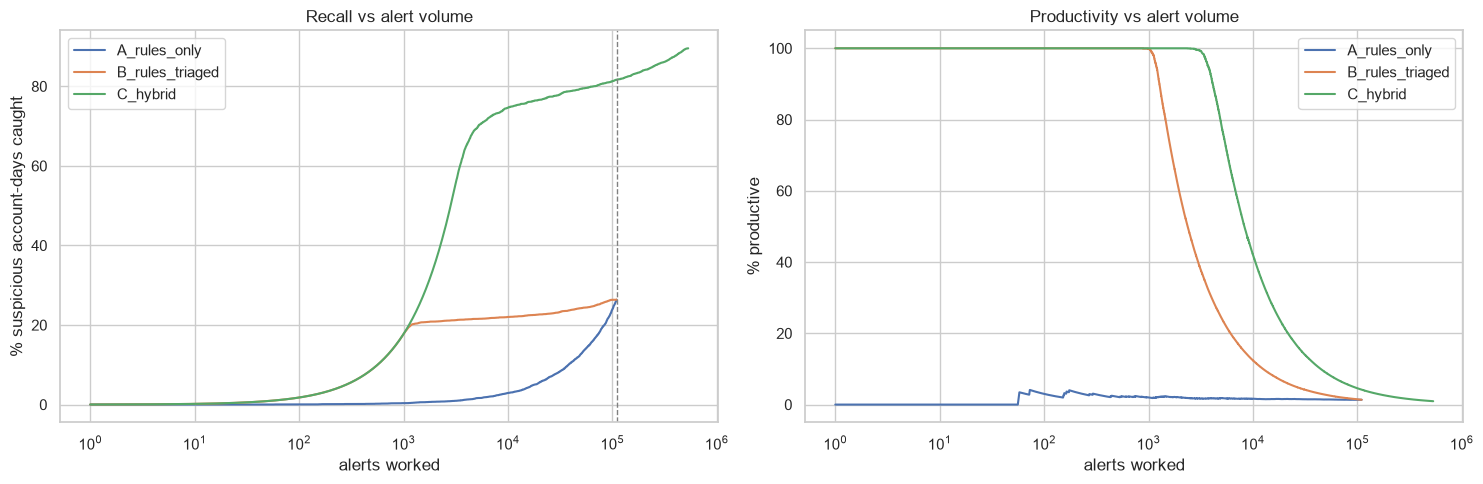

In [53]:
# H2: the three configurations, and the recall-vs-volume curve.
#
#   A  rules only      -- rules give no priority order, so the queue is worked in
#                         arbitrary order. Shuffled to represent that honestly.
#   B  rules + triage  -- same alerts, ranked by model score. Nothing new is
#                         detected; the gain is that the productive ones surface
#                         first, so a capacity cut loses less recall.
#   C  hybrid          -- rule alerts PLUS model-flagged account-days the rules
#                         never saw. This is the only config that can raise the
#                         recall ceiling.
CONFIGS = {
    "A_rules_only":    q_rules.sample(frac=1, random_state=CFG["seed"]).reset_index(drop=True),
    "B_rules_triaged": q_rules,
    "C_hybrid":        pd.concat([q_rules, q_model], ignore_index=True)
                         .sort_values("score", ascending=False).reset_index(drop=True),
}

def curve(q):
    tp  = q.is_tp.values.cumsum()
    vol = np.arange(1, len(q) + 1)
    return vol, tp / N_TRUTH, tp / vol      # volume, recall, precision

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for name, q in CONFIGS.items():
    v, r, p = curve(q)
    ax[0].plot(v, 100 * r, label=name)
    ax[1].plot(v, 100 * p, label=name)
ax[0].axvline(len(q_rules), ls="--", c="grey", lw=1)
ax[0].set_xlabel("alerts worked"); ax[0].set_ylabel("% suspicious account-days caught")
ax[0].set_title("Recall vs alert volume"); ax[0].legend(); ax[0].set_xscale("log")
ax[1].set_xlabel("alerts worked"); ax[1].set_ylabel("% productive")
ax[1].set_title("Productivity vs alert volume"); ax[1].legend(); ax[1].set_xscale("log")
plt.tight_layout(); plt.show()

In [54]:
# H3: the scorecard -- the table the dashboard is built from.
#
# Two questions a head of financial crime actually asks:
#   "If I hold recall, how much analyst effort do I save?"      -> volume_to_match
#   "If I hold headcount, how much more do I catch?"            -> recall_at_*
BASE_VOL = len(q_rules)
BASE_REC = q_rules.is_tp.sum() / N_TRUTH
CAPACITY_LEVELS = [0.25, 0.50, 1.00]     # fractions of the current alert volume

rows = []
for name, q in CONFIGS.items():
    v, r, p = curve(q)
    row = {"config": name, "queue_size": len(q)}
    for lvl in CAPACITY_LEVELS:
        idx = min(int(BASE_VOL * lvl), len(q)) - 1
        row[f"recall_at_{int(lvl*100)}pct_capacity"] = round(100 * r[idx], 1)
    hit = int(np.searchsorted(r, BASE_REC) + 1)
    row["vol_to_match_base_recall"] = min(hit, len(q))
    row["effort_saved_pct"] = round(100 * (1 - min(hit, len(q)) / BASE_VOL), 1)
    rows.append(row)

scorecard = pd.DataFrame(rows)
print(f"baseline: {BASE_VOL:,} alerts, {100*BASE_REC:.1f}% recall of {N_TRUTH:,} suspicious account-days")
print(f"analyst effort: {BASE_VOL * ALERT_MINUTES / 60 / PRODUCTIVE_HOURS:,.0f} analyst-days\n")
print(scorecard.to_string(index=False))

# ---------------------------------------------------------------------------
# READ THIS BEFORE QUOTING ANY OF THESE NUMBERS
# ---------------------------------------------------------------------------
# SAML-D's suspicious typologies are GENERATED from counterparty-count and
# velocity patterns -- which is exactly what snd_n_cp_7d, rcv_cnt_7d and friends
# measure. The model is therefore recovering the generator's own construction,
# and separability here is far higher than any production AML system achieves.
# Treat the SHAPE of these curves as the finding (triage reorders, hybrid raises
# the ceiling) and label the magnitudes as synthetic-data artefacts on the
# dashboard. A real programme would be delighted with a fraction of this.

baseline: 109,957 alerts, 26.4% recall of 5,640 suspicious account-days
analyst effort: 7,636 analyst-days

         config  queue_size  recall_at_25pct_capacity  recall_at_50pct_capacity  recall_at_100pct_capacity  vol_to_match_base_recall  effort_saved_pct
   A_rules_only      109957                       7.5                      13.9                       26.4                    109956               0.0
B_rules_triaged      109957                      23.0                      24.4                       26.4                    108649               1.2
       C_hybrid      533038                      77.5                      79.6                       81.6                      1487              98.6


In [56]:
# H4: does the hybrid close the coverage gaps the rules could not see?
#
# This is the argument for adding a model at all. Compared at EQUAL alert volume,
# so it is a like-for-like swap rather than "spend more and catch more".
truth_typ = con.execute("SELECT account, dt, typology FROM truth_days").df()

def coverage_by_typology(q, n_alerts, label):
    worked = q.head(int(n_alerts))[["account", "dt"]]
    hit = truth_typ.merge(worked, on=["account", "dt"], how="inner")
    tot = truth_typ.groupby("typology").size().rename("total")
    got = hit.groupby("typology").size().rename(label)
    return pd.concat([tot, got], axis=1).fillna(0)

cmp_cov = coverage_by_typology(CONFIGS["A_rules_only"], BASE_VOL, "rules_only")
cmp_cov["hybrid"] = coverage_by_typology(CONFIGS["C_hybrid"], BASE_VOL, "hybrid")["hybrid"]
cmp_cov["rules_pct"]  = 100 * cmp_cov.rules_only / cmp_cov.total
cmp_cov["hybrid_pct"] = 100 * cmp_cov.hybrid     / cmp_cov.total
cmp_cov["delta_pp"]   = cmp_cov.hybrid_pct - cmp_cov.rules_pct

print(f"typology coverage at equal volume ({BASE_VOL:,} alerts)\n")
print(cmp_cov[["total", "rules_pct", "hybrid_pct", "delta_pp"]]
        .sort_values("delta_pp", ascending=False).round(1).to_string())

typology coverage at equal volume (109,957 alerts)

                      total  rules_pct  hybrid_pct  delta_pp
typology                                                    
Bipartite               117       10.3        94.9      84.6
Layered_Fan_In          325       15.4        92.3      76.9
Smurfing                532       17.9        91.5      73.7
Cash_Withdrawal         662       19.3        91.1      71.8
Gather-Scatter          223       17.0        88.8      71.7
Scatter-Gather          154       19.5        90.3      70.8
Layered_Fan_Out         296       17.2        86.1      68.9
Stacked Bipartite       383       20.9        89.0      68.1
Single_large            129       25.6        89.1      63.6
Over-Invoicing           42       26.2        88.1      61.9
Deposit-Send            537       30.4        85.7      55.3
Cycle                   228       25.9        78.9      53.1
Fan_Out                 245       22.4        75.5      53.1
Fan_In                  176      

In [57]:
# ---------------------------------------------------------------------------
# TABLEAU EXPORT
# ---------------------------------------------------------------------------
# One tidy CSV per dashboard panel. Tableau prefers LONG format -- one row per
# observation with a category column -- rather than wide tables, because that is
# what lets a single worksheet colour or facet by series.
#
# NOTE: everything published to Tableau Public is publicly visible. That is fine
# for SAML-D, which is synthetic. Never point a Public workbook at real data.
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

n_score_days = con.execute("SELECT COUNT(DISTINCT dt) FROM score_f").fetchone()[0]
n_score_txn  = con.execute("SELECT COUNT(*) FROM score_f").fetchone()[0]
n_score_pos  = con.execute("SELECT SUM(y) FROM score_f").fetchone()[0]

# --- 1. Rule scorecard: cost and value per scenario -------------------------
# Marginal value is recomputed here because the R5 loop reused `rows`.
marg = []
for rid, _, _ in RULES:
    uniq = con.execute(f"""
        SELECT COUNT(DISTINCT txn_id) FROM rule_hits
        WHERE y = 1 AND rule_id = '{rid}'
          AND txn_id NOT IN (SELECT txn_id FROM rule_hits WHERE y = 1 AND rule_id <> '{rid}')
    """).fetchone()[0]
    marg.append({"rule_id": rid, "unique_caught": uniq})

rule_export = (perf.merge(pd.DataFrame(marg), on="rule_id", how="outer")
                   .fillna(0))
rule_export["fte_required"]     = rule_export.analyst_days / n_score_days
rule_export["pct_of_effort"]    = 100 * rule_export.analyst_days / rule_export.analyst_days.sum()
rule_export["days_per_detection"] = rule_export.analyst_days / rule_export.caught.replace(0, np.nan)
rule_export.sort_values("analyst_days", ascending=False).to_csv(OUT / "rule_scorecard.csv", index=False)

# --- 2. Alert funnel (long) -------------------------------------------------
funnel = pd.DataFrame([
    {"stage": "1. Transactions scanned", "count": int(n_score_txn)},
    {"stage": "2. Rule hits",            "count": int(con.execute("SELECT COUNT(*) FROM rule_hits").fetchone()[0])},
    {"stage": "3. Alerts raised",        "count": int(con.execute("SELECT COUNT(*) FROM alerts").fetchone()[0])},
    {"stage": "4. Productive alerts",    "count": int(con.execute("SELECT SUM(is_tp) FROM alerts").fetchone()[0])},
])
funnel.to_csv(OUT / "alert_funnel.csv", index=False)

# --- 3. Typology coverage, rules vs hybrid at equal volume (long) -----------
typ_long = (cmp_cov.reset_index()
            .melt(id_vars=["typology", "total"],
                  value_vars=["rules_pct", "hybrid_pct"],
                  var_name="config", value_name="coverage_pct"))
typ_long["config"] = typ_long.config.map({"rules_pct": "Rules only", "hybrid_pct": "Hybrid"})
typ_long.to_csv(OUT / "typology_coverage.csv", index=False)

# Rule-engine coverage over the full alert queue (the R5 view).
cov.to_csv(OUT / "rule_typology_coverage.csv", index=False)

# --- 4. Recall vs alert volume (long, downsampled) --------------------------
# The hybrid queue is ~500k points. Tableau will render it, but log-spaced
# sampling keeps the extract small and the curve shape identical on a log axis.
def downsample_curve(q, name, n_points=400):
    v, r, p = curve(q)
    idx = np.unique(np.geomspace(1, len(v), n_points).astype(int)) - 1
    return pd.DataFrame({"config":        name,
                         "alerts_worked": v[idx],
                         "recall_pct":    100 * r[idx],
                         "precision_pct": 100 * p[idx]})

curves = pd.concat([downsample_curve(q, name) for name, q in CONFIGS.items()],
                   ignore_index=True)
curves["config"] = curves.config.map({
    "A_rules_only":    "A - Rules only",
    "B_rules_triaged": "B - Rules + triage",
    "C_hybrid":        "C - Hybrid"})
curves["analyst_days"] = curves.alerts_worked * ALERT_MINUTES / 60 / PRODUCTIVE_HOURS
curves.to_csv(OUT / "recall_vs_volume.csv", index=False)

# --- 5. Configuration scorecard and thresholds ------------------------------
scorecard.to_csv(OUT / "config_scorecard.csv", index=False)
thresh_table.to_csv(OUT / "threshold_strategies.csv", index=False)

# --- 6. Run metadata --------------------------------------------------------
# Drives dashboard captions and, importantly, the synthetic-data disclaimer.
meta = pd.DataFrame([
    {"key": "scoring_period_days",   "value": n_score_days},
    {"key": "transactions_scored",   "value": int(n_score_txn)},
    {"key": "suspicious_txns",       "value": int(n_score_pos)},
    {"key": "suspicious_account_days", "value": int(N_TRUTH)},
    {"key": "enrichment_factor",     "value": round(W_NEG, 4)},
    {"key": "population_base_rate",  "value": round(POP_POS / POP_ROWS, 6)},
    {"key": "model_used",            "value": MODEL_NAME},
    {"key": "pr_auc_baseline",       "value": round(ap_base, 4)},
    {"key": "pr_auc_tuned",          "value": round(ap_tuned, 4)},
    {"key": "alert_minutes",         "value": ALERT_MINUTES},
    {"key": "productive_hours",      "value": PRODUCTIVE_HOURS},
    {"key": "total_analyst_days",    "value": round(perf.analyst_days.sum(), 1)},
    {"key": "fte_required",          "value": round(perf.analyst_days.sum() / n_score_days, 1)},
    {"key": "data_source",           "value": "SAML-D (synthetic)"},
    {"key": "disclaimer",            "value": "Synthetic data: typologies are generated from the "
                                              "velocity and counterparty patterns the model measures, "
                                              "so separability exceeds any production AML system."},
])
meta.to_csv(OUT / "run_metadata.csv", index=False)

for f in sorted(OUT.glob("*.csv")):
    print(f"{f.name:<32} {len(pd.read_csv(f)):>7,} rows")

# Reminder: .gitignore blanket-ignores *.csv. Add "!outputs/*.csv" if the
# workbook's data source should live in the repo.

alert_funnel.csv                       4 rows
config_scorecard.csv                   3 rows
recall_vs_volume.csv                 948 rows
rule_scorecard.csv                     8 rows
rule_typology_coverage.csv            17 rows
run_metadata.csv                      15 rows
threshold_strategies.csv               3 rows
typology_coverage.csv                 34 rows
